In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("emi_prediction_dataset.csv", low_memory=False)

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (404800, 27)

Dtypes:
 age                        object
gender                     object
marital_status             object
education                  object
monthly_salary             object
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
existing_loans             object
current_emi_amount        float64
credit_score              float64
bank_balance               object
emergency_fund            float64
emi_scenario               object
requested_amount          float64
requested_tenure            int64
emi_eligibility            object
max_monthly_emi           float64
dtype: object

Missing values:
 education         24

In [2]:
# Fix wrong datatypes (numbers stored as text)
for col in ["age", "monthly_salary", "bank_balance"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Check again after conversion
print("Missing after numeric conversion:\n", df.isnull().sum()[df.isnull().sum() > 0])

Missing after numeric conversion:
 age                  3
education         2404
monthly_salary    1993
monthly_rent      2426
credit_score      2420
bank_balance      4392
emergency_fund    2351
dtype: int64


In [3]:
# Numeric columns: fill missing with median
numeric_cols = ["monthly_rent", "credit_score", "bank_balance", "emergency_fund", "age", "monthly_salary"]
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns: fill missing with mode (most common value)
categorical_cols = ["education"]
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Final check
print("Missing values left:\n", df.isnull().sum().sum())
print("\nShape after cleaning:", df.shape)

Missing values left:
 0

Shape after cleaning: (404800, 27)


In [4]:
# Remove any invalid/impossible values
df = df[(df["age"] >= 18) & (df["age"] <= 70)]
df = df[df["monthly_salary"] > 0]
df["credit_score"] = df["credit_score"].clip(300, 850)

print("Shape after validity checks:", df.shape)
print("\nemi_eligibility distribution:\n", df["emi_eligibility"].value_counts(normalize=True))

Shape after validity checks: (404800, 27)

emi_eligibility distribution:
 emi_eligibility
Not_Eligible    0.772895
Eligible        0.183903
High_Risk       0.043202
Name: proportion, dtype: float64


In [5]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["emi_eligibility"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["emi_eligibility"]
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)
print("Saved: train.csv, val.csv, test.csv")

Train: (283360, 27)
Val: (60720, 27)
Test: (60720, 27)
Saved: train.csv, val.csv, test.csv


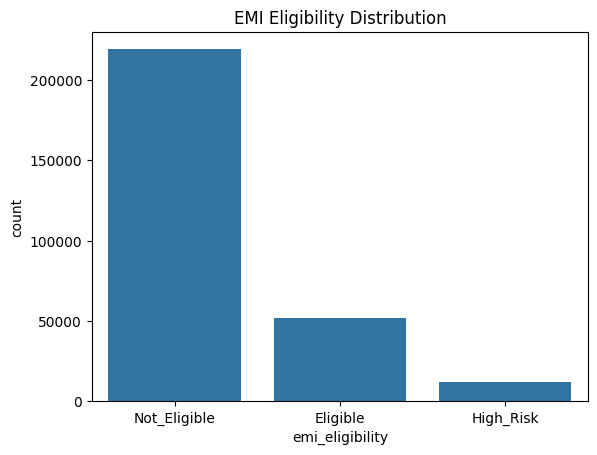

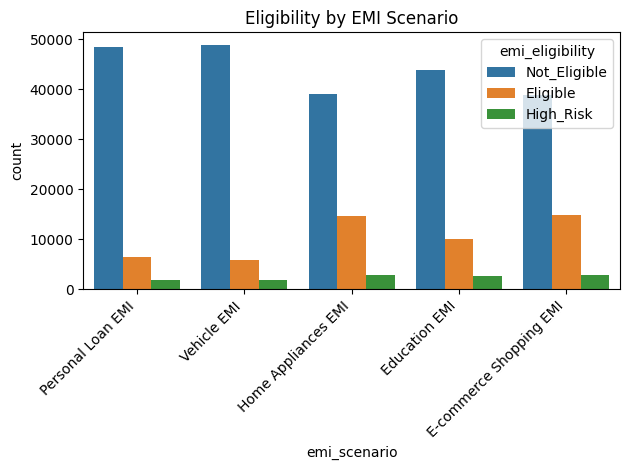

                 age  monthly_salary  years_of_employment   monthly_rent  \
count  283360.000000   283360.000000        283360.000000  283360.000000   
mean       38.881416    59438.066816             5.358999    5787.328758   
std         9.307225    43293.960555             6.067157    8628.869393   
min        26.000000     3967.000000             0.500000       0.000000   
25%        32.000000    35500.000000             1.200000       0.000000   
50%        38.000000    51700.000000             3.200000       0.000000   
75%        48.000000    72800.000000             7.200000   10500.000000   
max        59.000000   499970.000000            36.000000   80000.000000   

         family_size     dependents    school_fees   college_fees  \
count  283360.000000  283360.000000  283360.000000  283360.000000   
mean        2.941011       1.941011    4623.803642    4068.844579   
std         1.075220       1.075220    5065.482993    7321.056441   
min         1.000000       0.000000    

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("train.csv")

# 1. Eligibility distribution
sns.countplot(data=train_df, x="emi_eligibility")
plt.title("EMI Eligibility Distribution")
plt.show()

# 2. Eligibility across scenarios
sns.countplot(data=train_df, x="emi_scenario", hue="emi_eligibility")
plt.xticks(rotation=45, ha="right")
plt.title("Eligibility by EMI Scenario")
plt.tight_layout()
plt.show()

print(train_df.describe())

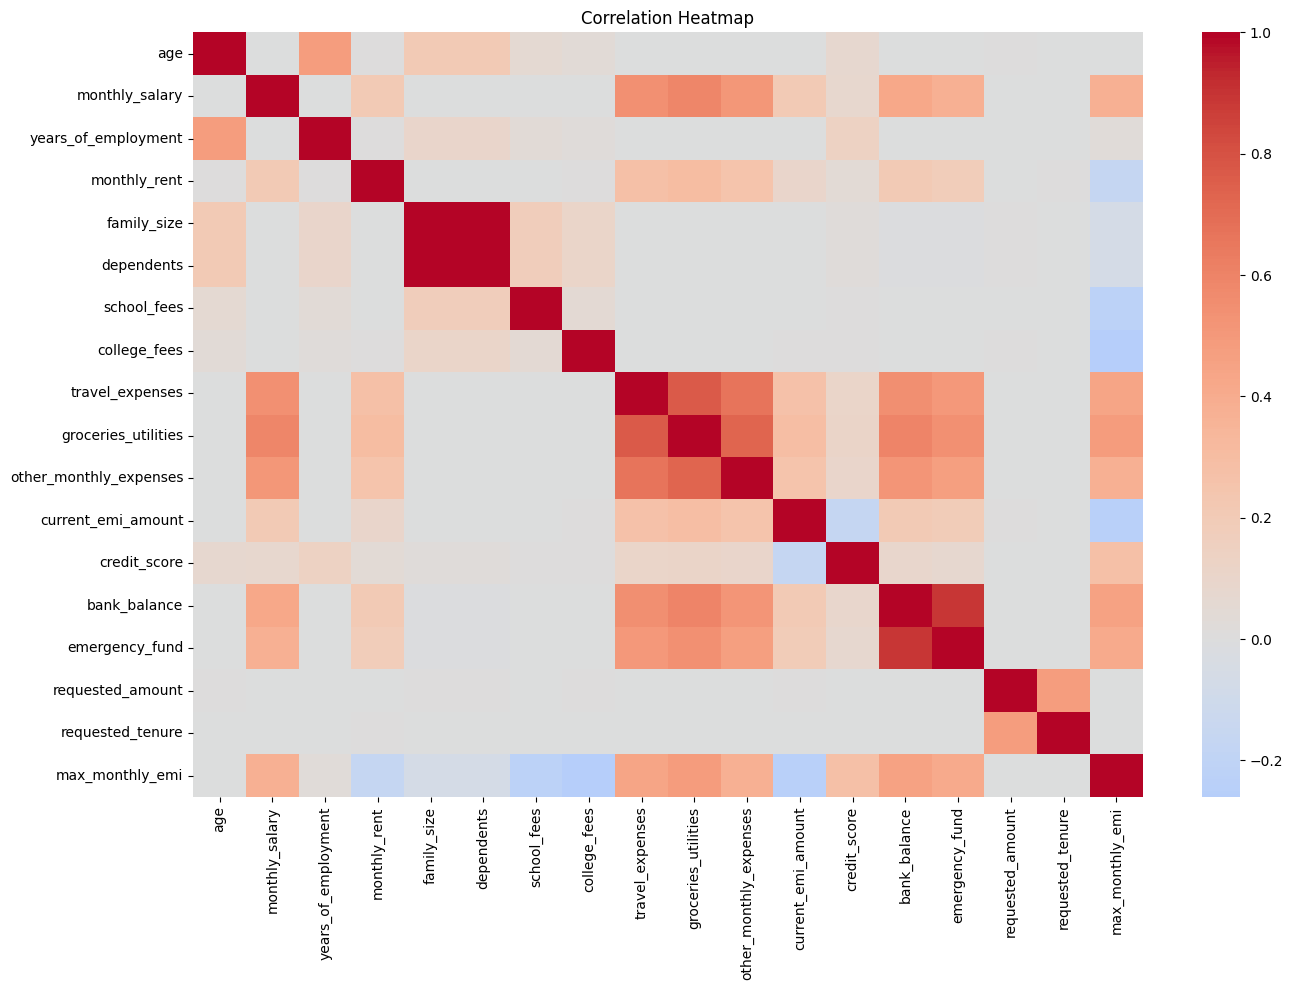

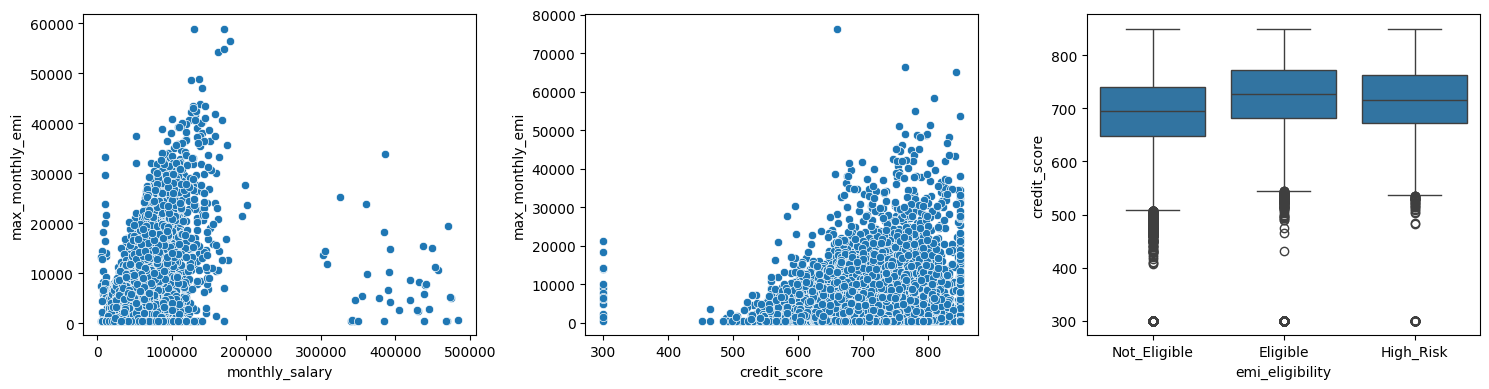

In [7]:
# Correlation heatmap for numeric features
numeric_cols = train_df.select_dtypes(include="number").columns
plt.figure(figsize=(14, 10))
sns.heatmap(train_df[numeric_cols].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# max_monthly_emi vs key features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=train_df.sample(5000), x="monthly_salary", y="max_monthly_emi", ax=axes[0])
sns.scatterplot(data=train_df.sample(5000), x="credit_score", y="max_monthly_emi", ax=axes[1])
sns.boxplot(data=train_df, x="emi_eligibility", y="credit_score", ax=axes[2])
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

def add_features(df):
    df = df.copy()
    total_expenses = (df["monthly_rent"] + df["school_fees"] + df["college_fees"] +
                       df["travel_expenses"] + df["groceries_utilities"] +
                       df["other_monthly_expenses"] + df["current_emi_amount"])

    df["total_expenses"] = total_expenses
    df["debt_to_income"] = df["current_emi_amount"] / df["monthly_salary"].replace(0, np.nan)
    df["expense_to_income"] = total_expenses / df["monthly_salary"].replace(0, np.nan)
    df["disposable_income"] = df["monthly_salary"] - total_expenses
    df["affordability_ratio"] = (df["requested_amount"] / df["requested_tenure"]) / df["monthly_salary"].replace(0, np.nan)
    df["savings_ratio"] = df["bank_balance"] / df["monthly_salary"].replace(0, np.nan)

    df.fillna(0, inplace=True)
    return df

train_df = add_features(train_df)
val_df = add_features(val_df)
test_df = add_features(test_df)

print(train_df[["debt_to_income", "expense_to_income", "disposable_income", "affordability_ratio", "savings_ratio"]].describe())

       debt_to_income  expense_to_income  disposable_income  \
count   283360.000000      283360.000000      283360.000000   
mean         0.083685           0.867053       14824.103035   
std          0.142435           0.636276       37637.060372   
min          0.000000           0.011144     -161883.000000   
25%          0.000000           0.606667         400.000000   
50%          0.000000           0.778943       10600.000000   
75%          0.174456           0.991543       22400.000000   
max          7.704465          31.291979      484780.000000   

       affordability_ratio  savings_ratio  
count        283360.000000  283360.000000  
mean              0.345940       4.449633  
std               0.456318       3.961457  
min               0.001211       0.020562  
25%               0.099893       2.348807  
50%               0.206355       4.237776  
75%               0.415459       6.150943  
max              17.613636     218.462139  


In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

categorical_cols = ["gender", "marital_status", "education", "employment_type",
                     "company_type", "house_type", "existing_loans", "emi_scenario"]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    val_df[col] = le.transform(val_df[col])
    test_df[col] = le.transform(test_df[col])
    encoders[col] = le

numeric_cols = ["age", "monthly_salary", "years_of_employment", "monthly_rent",
                "family_size", "dependents", "school_fees", "college_fees",
                "travel_expenses", "groceries_utilities", "other_monthly_expenses",
                "current_emi_amount", "credit_score", "bank_balance", "emergency_fund",
                "requested_amount", "requested_tenure", "total_expenses",
                "debt_to_income", "expense_to_income", "disposable_income",
                "affordability_ratio", "savings_ratio"]

scaler = StandardScaler()
train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
val_df[numeric_cols] = scaler.transform(val_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

print("Encoding + scaling done")
print(train_df.shape)

train_df.to_csv("train_fe.csv", index=False)
val_df.to_csv("val_fe.csv", index=False)
test_df.to_csv("test_fe.csv", index=False)
print("Saved: train_fe.csv, val_fe.csv, test_fe.csv")

Encoding + scaling done
(283360, 33)
Saved: train_fe.csv, val_fe.csv, test_fe.csv


In [10]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

train_df = pd.read_csv("train_fe.csv")
val_df = pd.read_csv("val_fe.csv")

# Features aur target alag karo
drop_cols = ["emi_eligibility", "max_monthly_emi"]
X_train = train_df.drop(columns=drop_cols)
X_val = val_df.drop(columns=drop_cols)

y_train = train_df["emi_eligibility"]
y_val = val_df["emi_eligibility"]

print("X_train:", X_train.shape, " y_train classes:", y_train.unique())

X_train: (283360, 31)  y_train classes: ['Not_Eligible' 'Eligible' 'High_Risk']


In [12]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred, average="weighted"))
print("Recall:", recall_score(y_val, y_pred, average="weighted"))
print("F1:", f1_score(y_val, y_pred, average="weighted"))

Accuracy: 0.9129940711462451
Precision: 0.8862899938440584
Recall: 0.9129940711462451
F1: 0.8938197802744268


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print("Precision:", precision_score(y_val, y_pred_rf, average="weighted"))
print("Recall:", recall_score(y_val, y_pred_rf, average="weighted"))
print("F1:", f1_score(y_val, y_pred_rf, average="weighted"))

Accuracy: 0.9491436100131753
Precision: 0.9373749483529059
Recall: 0.9491436100131753
F1: 0.9316882242198767


In [14]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost ko target numeric chahiye, string classes nahi chalte
le_target = LabelEncoder()
y_train_enc = le_target.fit_transform(y_train)
y_val_enc = le_target.transform(y_val)

xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                           random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train_enc)

y_pred_xgb = xgb_model.predict(X_val)

print("Accuracy:", accuracy_score(y_val_enc, y_pred_xgb))
print("Precision:", precision_score(y_val_enc, y_pred_xgb, average="weighted"))
print("Recall:", recall_score(y_val_enc, y_pred_xgb, average="weighted"))
print("F1:", f1_score(y_val_enc, y_pred_xgb, average="weighted"))
print("\nClasses order:", le_target.classes_)

Accuracy: 0.9780138339920948
Precision: 0.9768169379818742
Recall: 0.9780138339920948
F1: 0.9767250571909557

Classes order: ['Eligible' 'High_Risk' 'Not_Eligible']


In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

train_df = pd.read_csv("train_fe.csv")
val_df = pd.read_csv("val_fe.csv")

drop_cols = ["emi_eligibility", "max_monthly_emi"]
X_train = train_df.drop(columns=drop_cols)
X_val = val_df.drop(columns=drop_cols)

y_train_reg = train_df["max_monthly_emi"]
y_val_reg = val_df["max_monthly_emi"]

print("X_train:", X_train.shape)
print("y_train_reg range:", y_train_reg.min(), "-", y_train_reg.max())

X_train: (283360, 31)
y_train_reg range: 500.0 - 89166.0


In [16]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train, y_train_reg)

y_pred_lin = lin_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred_lin))
mae = mean_absolute_error(y_val_reg, y_pred_lin)
r2 = r2_score(y_val_reg, y_pred_lin)
mape = np.mean(np.abs((y_val_reg - y_pred_lin) / y_val_reg)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("MAPE:", mape)

RMSE: 4116.767938522461
MAE: 2942.714352634749
R2: 0.7198654840920093
MAPE: 189.4270324545482


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train_reg)

y_pred_rf = rf_reg.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred_rf))
mae = mean_absolute_error(y_val_reg, y_pred_rf)
r2 = r2_score(y_val_reg, y_pred_rf)
mape = np.mean(np.abs((y_val_reg - y_pred_rf) / y_val_reg)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("MAPE:", mape)

RMSE: 937.1849154300099
MAE: 244.52220885931288
R2: 0.9854820790049897
MAPE: 6.837001894161303


In [18]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_reg.fit(X_train, y_train_reg)

y_pred_xgb_reg = xgb_reg.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred_xgb_reg))
mae = mean_absolute_error(y_val_reg, y_pred_xgb_reg)
r2 = r2_score(y_val_reg, y_pred_xgb_reg)
mape = np.mean(np.abs((y_val_reg - y_pred_xgb_reg) / y_val_reg)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("MAPE:", mape)

RMSE: 666.8650575791783
MAE: 206.37659858443297
R2: 0.9926492818154311
MAPE: 8.140393724682832


In [19]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              mean_squared_error, mean_absolute_error, r2_score)

mlflow.set_experiment("EMIPredict_AI")

train_df = pd.read_csv("train_fe.csv")
val_df = pd.read_csv("val_fe.csv")

X_train = train_df.drop(columns=["emi_eligibility", "max_monthly_emi"])
X_val = val_df.drop(columns=["emi_eligibility", "max_monthly_emi"])

y_train_cls = train_df["emi_eligibility"]
y_val_cls = val_df["emi_eligibility"]

le_target = LabelEncoder()
y_train_cls_enc = le_target.fit_transform(y_train_cls)
y_val_cls_enc = le_target.transform(y_val_cls)

y_train_reg = train_df["max_monthly_emi"]
y_val_reg = val_df["max_monthly_emi"]

print("Setup done. mlflow experiment 'EMIPredict_AI' set.")

Setup done. mlflow experiment 'EMIPredict_AI' set.


In [20]:
# ---- Logistic Regression ----
with mlflow.start_run(run_name="LogisticRegression_Classifier"):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train_cls)
    y_pred = model.predict(X_val)

    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_metric("accuracy", accuracy_score(y_val_cls, y_pred))
    mlflow.log_metric("precision", precision_score(y_val_cls, y_pred, average="weighted"))
    mlflow.log_metric("recall", recall_score(y_val_cls, y_pred, average="weighted"))
    mlflow.log_metric("f1_score", f1_score(y_val_cls, y_pred, average="weighted"))
    mlflow.sklearn.log_model(model, "model")

# ---- Random Forest Classifier ----
with mlflow.start_run(run_name="RandomForest_Classifier"):
    model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train_cls)
    y_pred = model.predict(X_val)

    mlflow.log_param("model_type", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 15)
    mlflow.log_metric("accuracy", accuracy_score(y_val_cls, y_pred))
    mlflow.log_metric("precision", precision_score(y_val_cls, y_pred, average="weighted"))
    mlflow.log_metric("recall", recall_score(y_val_cls, y_pred, average="weighted"))
    mlflow.log_metric("f1_score", f1_score(y_val_cls, y_pred, average="weighted"))
    mlflow.sklearn.log_model(model, "model")

# ---- XGBoost Classifier ----
with mlflow.start_run(run_name="XGBoost_Classifier"):
    model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train_cls_enc)
    y_pred = model.predict(X_val)

    mlflow.log_param("model_type", "XGBClassifier")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_metric("accuracy", accuracy_score(y_val_cls_enc, y_pred))
    mlflow.log_metric("precision", precision_score(y_val_cls_enc, y_pred, average="weighted"))
    mlflow.log_metric("recall", recall_score(y_val_cls_enc, y_pred, average="weighted"))
    mlflow.log_metric("f1_score", f1_score(y_val_cls_enc, y_pred, average="weighted"))
    mlflow.xgboost.log_model(model, "model")

print("All 3 classification models logged to MLflow")

2026/08/13 18:45:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/13 18:46:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/13 18:46:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


All 3 classification models logged to MLflow


In [21]:
# ---- Linear Regression ----
with mlflow.start_run(run_name="LinearRegression_Regressor"):
    model = LinearRegression()
    model.fit(X_train, y_train_reg)
    y_pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred))
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mean_absolute_error(y_val_reg, y_pred))
    mlflow.log_metric("r2", r2_score(y_val_reg, y_pred))
    mlflow.sklearn.log_model(model, "model")

# ---- Random Forest Regressor ----
with mlflow.start_run(run_name="RandomForest_Regressor"):
    model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train_reg)
    y_pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred))
    mlflow.log_param("model_type", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 15)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mean_absolute_error(y_val_reg, y_pred))
    mlflow.log_metric("r2", r2_score(y_val_reg, y_pred))
    mlflow.sklearn.log_model(model, "model")

# ---- XGBoost Regressor ----
with mlflow.start_run(run_name="XGBoost_Regressor"):
    model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train_reg)
    y_pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred))
    mlflow.log_param("model_type", "XGBRegressor")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mean_absolute_error(y_val_reg, y_pred))
    mlflow.log_metric("r2", r2_score(y_val_reg, y_pred))
    mlflow.xgboost.log_model(model, "model")

print("All 3 regression models logged to MLflow")

2026/08/13 18:47:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/13 18:50:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/13 18:51:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


All 3 regression models logged to MLflow


In [25]:
from mlflow import MlflowClient

client = MlflowClient()

# Register best classification model
classifier_run_id = "f3b43124a4e34d438ad89afec3a4d661"
mlflow.register_model(
    model_uri=f"runs:/{classifier_run_id}/model",
    name="EMIPredict_Classifier"
)

# Register best regression model
regressor_run_id = "fd59238b991a4e1390d89764e29482c5"
mlflow.register_model(
    model_uri=f"runs:/{regressor_run_id}/model",
    name="EMIPredict_Regressor"
)

print("Both models registered successfully")

Successfully registered model 'EMIPredict_Classifier'.
2026/08/13 19:02:43 WARNING mlflow.tracking._model_registry.fluent: Run with id f3b43124a4e34d438ad89afec3a4d661 has no artifacts at artifact path 'model', registering model based on models:/m-754284f02fc649dd832de19e6cd1f658 instead
Created version '1' of model 'EMIPredict_Classifier'.
Successfully registered model 'EMIPredict_Regressor'.
2026/08/13 19:02:47 WARNING mlflow.tracking._model_registry.fluent: Run with id fd59238b991a4e1390d89764e29482c5 has no artifacts at artifact path 'model', registering model based on models:/m-c4b23f391af240538dce7680a4104092 instead


Both models registered successfully


Created version '1' of model 'EMIPredict_Regressor'.


In [26]:
import pickle

with open("best_classifier.pkl", "wb") as f:
    pickle.dump(xgb_model, f)  

with open("best_regressor.pkl", "wb") as f:
    pickle.dump(xgb_reg, f)  

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le_target, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("All models and preprocessors saved as .pkl files")

All models and preprocessors saved as .pkl files


In [28]:
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier, XGBRegressor

train_df = pd.read_csv("train_fe.csv")

X_train = train_df.drop(columns=["emi_eligibility", "max_monthly_emi"])
y_train_cls = train_df["emi_eligibility"]
y_train_reg = train_df["max_monthly_emi"]

le_target = LabelEncoder()
y_train_cls_enc = le_target.fit_transform(y_train_cls)

best_classifier = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
best_classifier.fit(X_train, y_train_cls_enc)

best_regressor = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
best_regressor.fit(X_train, y_train_reg)

with open("best_classifier.pkl", "wb") as f:
    pickle.dump(best_classifier, f)

with open("best_regressor.pkl", "wb") as f:
    pickle.dump(best_regressor, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le_target, f)

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(list(X_train.columns), f)

print("Saved: best_classifier.pkl, best_regressor.pkl, label_encoder.pkl, feature_columns.pkl")

Saved: best_classifier.pkl, best_regressor.pkl, label_encoder.pkl, feature_columns.pkl


In [29]:
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier, XGBRegressor

train_df = pd.read_csv("train.csv")

def add_features(df):
    df = df.copy()
    total_expenses = (df["monthly_rent"] + df["school_fees"] + df["college_fees"] +
                       df["travel_expenses"] + df["groceries_utilities"] +
                       df["other_monthly_expenses"] + df["current_emi_amount"])
    df["total_expenses"] = total_expenses
    df["debt_to_income"] = df["current_emi_amount"] / df["monthly_salary"].replace(0, np.nan)
    df["expense_to_income"] = total_expenses / df["monthly_salary"].replace(0, np.nan)
    df["disposable_income"] = df["monthly_salary"] - total_expenses
    df["affordability_ratio"] = (df["requested_amount"] / df["requested_tenure"]) / df["monthly_salary"].replace(0, np.nan)
    df["savings_ratio"] = df["bank_balance"] / df["monthly_salary"].replace(0, np.nan)
    df.fillna(0, inplace=True)
    return df

train_df = add_features(train_df)

# Categorical encode
categorical_cols = ["gender", "marital_status", "education", "employment_type",
                     "company_type", "house_type", "existing_loans", "emi_scenario"]
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    label_encoders[col] = le

# Numeric scale
numeric_cols = ["age", "monthly_salary", "years_of_employment", "monthly_rent",
                "family_size", "dependents", "school_fees", "college_fees",
                "travel_expenses", "groceries_utilities", "other_monthly_expenses",
                "current_emi_amount", "credit_score", "bank_balance", "emergency_fund",
                "requested_amount", "requested_tenure", "total_expenses",
                "debt_to_income", "expense_to_income", "disposable_income",
                "affordability_ratio", "savings_ratio"]

scaler = StandardScaler()
train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])

# X / y
X_train = train_df.drop(columns=["emi_eligibility", "max_monthly_emi"])
y_train_cls = train_df["emi_eligibility"]
y_train_reg = train_df["max_monthly_emi"]

le_target = LabelEncoder()
y_train_cls_enc = le_target.fit_transform(y_train_cls)

# Models train
best_classifier = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
best_classifier.fit(X_train, y_train_cls_enc)

best_regressor = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
best_regressor.fit(X_train, y_train_reg)

# Save everything
with open("best_classifier.pkl", "wb") as f: pickle.dump(best_classifier, f)
with open("best_regressor.pkl", "wb") as f: pickle.dump(best_regressor, f)
with open("label_encoder.pkl", "wb") as f: pickle.dump(le_target, f)
with open("scaler.pkl", "wb") as f: pickle.dump(scaler, f)
with open("categorical_encoders.pkl", "wb") as f: pickle.dump(label_encoders, f)
with open("feature_columns.pkl", "wb") as f: pickle.dump(list(X_train.columns), f)

print("All saved: models, scaler, encoders, feature_columns")

All saved: models, scaler, encoders, feature_columns


In [30]:
import streamlit as st
import pandas as pd
import numpy as np
import pickle

st.set_page_config(page_title="EMIPredict AI", layout="wide")

@st.cache_resource
def load_models():
    with open("best_classifier.pkl", "rb") as f:
        classifier = pickle.load(f)
    with open("best_regressor.pkl", "rb") as f:
        regressor = pickle.load(f)
    with open("label_encoder.pkl", "rb") as f:
        le_target = pickle.load(f)
    with open("scaler.pkl", "rb") as f:
        scaler = pickle.load(f)
    with open("categorical_encoders.pkl", "rb") as f:
        cat_encoders = pickle.load(f)
    with open("feature_columns.pkl", "rb") as f:
        feature_cols = pickle.load(f)
    return classifier, regressor, le_target, scaler, cat_encoders, feature_cols

classifier, regressor, le_target, scaler, cat_encoders, feature_cols = load_models()

st.title("EMIPredict AI — Financial Risk Assessment Platform")
st.write("Enter applicant details to check EMI eligibility and maximum safe EMI amount.")

page = st.sidebar.radio("Navigate", ["Predict", "About"])

if page == "About":
    st.write("This platform uses XGBoost models trained on 400K+ financial records to predict EMI eligibility and safe EMI amounts.")
else:
    st.header("Applicant Details")
    st.info("Prediction form coming in next step")

2026-08-13 19:33:44.467 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-13 19:33:44.492 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-13 19:33:44.617 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-13 19:33:50.211 
  command:

    streamlit run C:\Users\panka\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-08-13 19:33:50.220 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-13 19:33:50.221 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-13 19